# Notebook 03: Paralelismo, Benchmarks y Patrones Avanzados

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/fdd_p26/blob/main/clase/16_computo/code/03_paralelismo_benchmarks.ipynb)

**Módulo 16 — Clase 3**

Este notebook acompaña los archivos `04b_asyncio_patrones.md`, `05_paralelismo.md`, `06_librerias_y_decision.md`.

Secciones **** se trabajan durante la sesión.  
Secciones **** se completan después.

---

In [ ]:
import asyncio
import time
import threading
import os
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

print(f'Python {sys.version}')
print(f'CPU cores disponibles: {os.cpu_count()}')

## Sección 1: create_task vs gather — trabajo intermedio "gratis"

**Qué vamos a ver:** `create_task` te permite lanzar una coroutine en background y hacer trabajo independiente *mientras espera*. Ese trabajo ocurre "gratis" — no suma al tiempo total.

**La diferencia clave:**
```
# Con gather — barrera:
await asyncio.gather(tarea_A(), trabajo_B())
# → espera a AMBAS antes de continuar
# → T_total = max(T_A, T_B)   (si son independientes)

# Con create_task — flexible:
tarea_A = asyncio.create_task(fn_A())   # A empieza en background ahora
resultado_B = trabajo_B()               # trabajo mientras A espera
resultado_A = await tarea_A             # punto de dependencia real
# → si T_B < T_A: resultado_B fue "gratis" (dentro del wait de A)
# → T_total = max(T_A, T_B)   (igual que gather, pero con control de flujo)
```

**Predicción:**
- `tarea_A` tarda 1.0s (I/O-bound), `trabajo_B` tarda ~0.1s (CPU)
- Con `create_task`: T_total ≈ **1.0s** — B ocurre dentro del wait de A
- Sin `create_task` (secuencial): T_total ≈ **1.1s** — B suma

Corre la celda. ¿El tiempo de B se "perdió" o se "ganó"?

> Referencia: `04b_asyncio_patrones.md` — sección "asyncio.create_task"

In [ ]:
async def tarea_io(nombre: str, duracion: float) -> str:
    """Simula I/O-bound: wait(τᵢ) ≠ ∅"""
    await asyncio.sleep(duracion)
    return f"{nombre} completada"

def trabajo_cpu_ligero(n: int) -> int:
    """Trabajo CPU-bound ligero: exec(τⱼ) mientras τᵢ espera"""
    return sum(range(n))

# --- Comparación: gather vs create_task ---

# gather: barrera — espera TODAS antes de continuar
print("=== gather: barrera ===")
t0 = time.perf_counter()
r1, r2 = await asyncio.gather(
    tarea_io("A", 1.0),
    tarea_io("B", 1.0),
)
t_gather = time.perf_counter() - t0
print(f"Resultados: {r1}, {r2}")
print(f"Tiempo: {t_gather:.2f}s (esperado ~1s)")
print()

# create_task: lanzar y continuar con trabajo intermedio
print("=== create_task + trabajo intermedio ===")
t0 = time.perf_counter()

# ① Lanzar τᵢ en background
tarea_a = asyncio.create_task(tarea_io("A", 1.0))

# ② Trabajo independiente DURANTE el wait de A
t_trabajo = time.perf_counter()
resultado_cpu = trabajo_cpu_ligero(5_000_000)   # ~200ms de CPU
t_trabajo = time.perf_counter() - t_trabajo
print(f"  Trabajo CPU completado en {t_trabajo:.2f}s (durante wait de A)")

# ③ Punto de dependencia: necesitamos el resultado de A
resultado_a = await tarea_a
t_create_task = time.perf_counter() - t0

print(f"  {resultado_a}")
print(f"Tiempo total: {t_create_task:.2f}s (esperado ~max(1s, tiempo_cpu))")
print()
print(f"Observa: el trabajo CPU ({t_trabajo:.2f}s) fue 'gratis' — ocurrió durante el wait de A.")
print(f"Sin create_task, hubiera sumado {1.0 + t_trabajo:.2f}s en lugar de {t_create_task:.2f}s")

## Sección 2: as_completed — procesar resultados conforme llegan

**Qué vamos a ver:** cuando las tareas tienen duraciones **variables**, `gather` introduce latencia innecesaria: bloquea hasta que la tarea más lenta termina antes de darte cualquier resultado. `as_completed` te da cada resultado en cuanto está disponible.

**La diferencia:**
```
Latencias: Wikipedia=0.5s, ArXiv=2.1s, GitHub=0.8s, PubMed=1.5s, DuckDuck=0.3s

Con gather:
  t=0   → lanza las 5 búsquedas
  t=2.1 → gather devuelve TODOS los resultados (espera a ArXiv)
  → tienes que esperar 2.1s aunque DuckDuck terminó en 0.3s

Con as_completed:
  t=0.3 → procesas DuckDuck (el primero en llegar)
  t=0.5 → procesas Wikipedia
  t=0.8 → procesas GitHub
  t=1.5 → procesas PubMed
  t=2.1 → procesas ArXiv
  → el primer resultado llega 7× más rápido que con gather
```

**Predicción:**
- El primer resultado de `as_completed` debería llegar en **~0.3s** (DuckDuck)
- El orden de llegada debería ser: DuckDuck, Wikipedia, GitHub, PubMed, ArXiv

Corre la celda y verifica el orden y los tiempos. ¿Coincide con la predicción?

> **Nota técnica:** `asyncio.as_completed()` devuelve un iterador regular (`for`, no `async for`) hasta Python 3.12.

> Referencia: `04b_asyncio_patrones.md` — sección "asyncio.as_completed"

In [ ]:
import random

async def buscar_fuente(nombre: str, latencia: float) -> str:
    """Simula búsqueda en una fuente externa con latencia variable"""
    await asyncio.sleep(latencia)
    return f"resultado de {nombre} (tardó {latencia:.1f}s)"

fuentes = [
    ("Wikipedia", 0.5),
    ("ArXiv",     2.1),
    ("GitHub",    0.8),
    ("PubMed",    1.5),
    ("DuckDuck",  0.3),
]

# --- Con gather: espera el más lento ---
print("=== asyncio.gather: espera al más lento ===")
t0 = time.perf_counter()
resultados = await asyncio.gather(
    *[buscar_fuente(nombre, lat) for nombre, lat in fuentes]
)
t_gather = time.perf_counter() - t0
print(f"Todos los resultados disponibles a los {t_gather:.2f}s")
for r in resultados:
    print(f"  {r}")
print()

# --- Con as_completed: procesar conforme llegan ---
# Nota: as_completed() devuelve un iterador regular (no async) hasta Python 3.12
print("=== asyncio.as_completed: procesa conforme llegan ===")
t0 = time.perf_counter()
tareas = [asyncio.create_task(buscar_fuente(n, l)) for n, l in fuentes]

orden_llegada = []
for coro in asyncio.as_completed(tareas):
    resultado = await coro
    t_llegada = time.perf_counter() - t0
    print(f"  t={t_llegada:.2f}s → {resultado}")
    orden_llegada.append(resultado)

print()
print("Observa: el orden de llegada es por latencia, no por orden de creación.")
print("El resultado más rápido (DuckDuck, 0.3s) llega primero aunque fue creado al final.")

---

## Sección 3: asyncio.Queue — productor-consumidor

**TAREA — implementación guiada**

El patrón productor-consumidor desacopla la velocidad de llegada de peticiones de la velocidad de procesamiento. La cola actúa como buffer con backpressure natural: si los consumidores no dan abasto, el productor se pausa automáticamente.

**El escenario:**
```
Productor → genera 10 peticiones a ritmo de 1 cada 0.5s
Consumidores (N workers) → cada petición tarda 0.5s en procesarse

Con 1 worker:  cola crece continuamente → T_total = 10 × 0.5s = 5s
Con 2 workers: producción ≈ consumo   → T_total ≈ 5s (equilibrado)
Con 3 workers: consumo > producción   → T_total ≈ 5s (workers esperan)
```

**Pistas de implementación:**
- `await queue.put(item)`: el productor se pausa si `maxsize` está lleno
- `await queue.get()`: el worker se pausa si la cola está vacía
- Usa un **sentinel** (`None`) para señalar al worker que no hay más trabajo
- Con N workers, necesitas N sentinels (uno por worker)

**Qué observar:** ¿cambia el tiempo total al variar `n_workers` de 1 a 3? ¿Por qué?

> Referencia: `04b_asyncio_patrones.md` — sección "asyncio.Queue"

In [ ]:
# TAREA 3: Implementar el patrón productor-consumidor
#
# Escenario: un productor genera 10 peticiones de chatbot a ritmo de 1 cada 0.5s.
# N workers las procesan (cada una tarda 0.5s).
# Mide: ¿cuándo termina todo si hay 1, 2 o 3 workers?

import asyncio
import time

N_PETICIONES = 10
RITMO_PRODUCCION = 0.5   # segundos entre peticiones
T_PROCESAMIENTO = 0.5    # segundos que tarda cada petición


async def productor(queue: asyncio.Queue, n: int, n_workers: int):
    """Genera n peticiones y al final envía un sentinel por cada worker."""
    for i in range(n):
        await queue.put(f"peticion_{i}")
        await asyncio.sleep(RITMO_PRODUCCION)
    # Sentinel: señal de fin para cada worker
    for _ in range(n_workers):
        await queue.put(None)


async def worker(queue: asyncio.Queue, nombre: str, resultados: list):
    """Consume peticiones hasta recibir el sentinel (None)."""
    while True:
        item = await queue.get()
        if item is None:          # sentinel → terminar
            break
        await asyncio.sleep(T_PROCESAMIENTO)
        resultados.append(f"{nombre} procesó {item}")


async def run_benchmark(n_workers: int) -> float:
    queue = asyncio.Queue(maxsize=5)  # backpressure: pausa al productor si la cola se llena
    resultados = []
    t0 = time.perf_counter()
    # Lanzar workers en background
    workers = [asyncio.create_task(worker(queue, f"W{i}", resultados))
               for i in range(n_workers)]
    # El productor corre en el event loop principal
    await productor(queue, N_PETICIONES, n_workers)
    # Esperar a que todos los workers terminen
    await asyncio.gather(*workers)
    return time.perf_counter() - t0


async def main():
    print(f"N_PETICIONES={N_PETICIONES}, RITMO={RITMO_PRODUCCION}s, T_proc={T_PROCESAMIENTO}s\n")
    print(f"{'Workers':<10} {'T_total (s)':<15} Observación")
    print("-" * 55)
    for n in [1, 2, 3]:
        t = await run_benchmark(n)
        if n == 1:
            obs = "cola crece → serializado"
        elif n == 2:
            obs = "producción ≈ consumo (equilibrado)"
        else:
            obs = "workers esperan al productor"
        print(f"{n:<10} {t:<15.2f} {obs}")

    print("\n→ El cuello de botella es el ritmo del productor (5s en total),")
    print("  por eso T_total ≈ 5s con 2 o 3 workers.")

await main()


## Sección 4: fire-and-forget — excepción silenciada vs tracked

**TAREA — demostrar el bug y corregirlo**

asyncio silencia las excepciones de tareas que nadie observa. Esto es un bug difícil de detectar en producción: el handler falla, el usuario no recibe respuesta, y el log queda vacío.

**Por qué ocurre:**
```
asyncio.create_task(handler())   # lanza la tarea
# Si handler() lanza ValueError después de 0.1s:
#   → la excepción queda en el objeto Task
#   → nadie hace await de esa tarea
#   → Python emite RuntimeWarning al final, pero el programa continúa
#   → en producción, ese warning se pierde en el log
```

**Qué demostrar:**
1. Lanza `tarea_que_falla()` como fire-and-forget
2. Espera más tiempo del que tarda en fallar (`await asyncio.sleep(0.5)`)
3. Confirma que no viste ningún error en el output
4. Implementa `add_done_callback` con una función que registre el error

**Pista para el fix:**
```python
def _registrar_error(tarea):
    if not tarea.cancelled() and tarea.exception():
        print(f"ERROR: {tarea.exception()}")

t = asyncio.create_task(fn())
t.add_done_callback(_registrar_error)
```

**Qué observar:** ¿cuándo se llama el callback — inmediatamente, o cuando la tarea termina?

> Referencia: `04b_asyncio_patrones.md` — anti-patrón "Fire-and-forget sin tracking"

In [5]:
# TAREA 4: Demostrar fire-and-forget con excepción silenciada y corregirlo

import asyncio

async def tarea_que_falla():
    await asyncio.sleep(0.1)
    raise ValueError("¡Error en la tarea!")


# === Anti-patrón: fire-and-forget sin tracking ===
print("=== Anti-patrón: fire-and-forget ===")
t = asyncio.create_task(tarea_que_falla())   # lanza la tarea en background
await asyncio.sleep(0.5)                      # la excepción ocurre aquí, pero...
print("No se vio ningún error — ¡la excepción fue silenciada!")
print("(Python puede emitir un RuntimeWarning al final, pero no interrumpe el programa)")
print()


# === Patrón correcto: add_done_callback ===
def _registrar_error(tarea):
    """Callback que se ejecuta cuando la tarea termina (con o sin error)."""
    if tarea.cancelled():
        print("[CALLBACK] Tarea cancelada.")
    elif tarea.exception():
        print(f"[CALLBACK] ERROR capturado: {tarea.exception()}")
    else:
        print(f"[CALLBACK] Tarea completada con resultado: {tarea.result()}")

print("=== Patrón correcto: add_done_callback ===")
t2 = asyncio.create_task(tarea_que_falla())
t2.add_done_callback(_registrar_error)   # se registra ahora, se llama cuando termina
await asyncio.sleep(0.5)
print("El callback se ejecutó cuando la tarea terminó, no inmediatamente.")
print("→ Así ninguna excepción pasa desapercibida en producción.")


=== Anti-patrón: fire-and-forget ===
No se vio ningún error — ¡la excepción fue silenciada!
(Python puede emitir un RuntimeWarning al final, pero no interrumpe el programa)

=== Patrón correcto: add_done_callback ===
[CALLBACK] ERROR capturado: ¡Error en la tarea!
El callback se ejecutó cuando la tarea terminó, no inmediatamente.
→ Así ninguna excepción pasa desapercibida en producción.


## Sección 5: Benchmark asyncio vs threading — I/O-bound

Compara asyncio y ThreadPoolExecutor para tareas I/O-bound.
Ambos deberían funcionar — ¿cuál es más rápido y más simple?

Benchmark: 20 tareas I/O-bound de 0.2s cada una
Secuencial: 4.0s  |  Concurrente esperado: ~0.2s

ThreadPoolExecutor (20 workers): 0.207s  (speedup 19.3×)


Task exception was never retrieved
future: <Task finished name='Task-28' coro=<tarea_que_falla() done, defined at /var/folders/ww/pkdsqpgj0wgfqd6sxz0h3jjr0000gn/T/ipykernel_32831/2725308858.py:5> exception=ValueError('¡Error en la tarea!')>
Traceback (most recent call last):
  File "/var/folders/ww/pkdsqpgj0wgfqd6sxz0h3jjr0000gn/T/ipykernel_32831/2725308858.py", line 7, in tarea_que_falla
    raise ValueError("¡Error en la tarea!")
ValueError: ¡Error en la tarea!


asyncio.gather   (20 tareas):   0.203s  (speedup 19.7×)

Overhead threading/asyncio: 1.02×

Cuándo usar cada uno:
  asyncio:   librería async disponible (aiohttp, asyncpg) — preferible
  threading: solo librerías síncronas (requests, psycopg2) — funciona, escala peor


FileNotFoundError: [Errno 2] No such file or directory: '../images/bench_io_threading_vs_async.png'

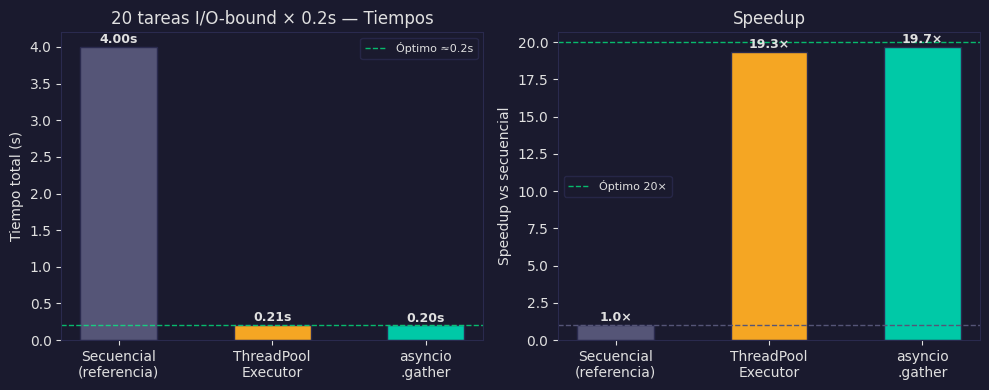

In [6]:
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

def io_bound_sync(duracion: float) -> str:
    time.sleep(duracion)
    return "resultado"

async def io_bound_async(duracion: float) -> str:
    await asyncio.sleep(duracion)
    return "resultado"

N   = 20
DUR = 0.2
t_seq = N * DUR

print(f"Benchmark: {N} tareas I/O-bound de {DUR}s cada una")
print(f"Secuencial: {t_seq:.1f}s  |  Concurrente esperado: ~{DUR:.1f}s\n")

# --- ThreadPoolExecutor ---
t0 = time.perf_counter()
with ThreadPoolExecutor(max_workers=N) as pool:
    [f.result() for f in [pool.submit(io_bound_sync, DUR) for _ in range(N)]]
t_thread = time.perf_counter() - t0
print(f"ThreadPoolExecutor ({N} workers): {t_thread:.3f}s  (speedup {t_seq/t_thread:.1f}×)")

# --- asyncio.gather ---
t0 = time.perf_counter()
await asyncio.gather(*[io_bound_async(DUR) for _ in range(N)])
t_async = time.perf_counter() - t0
print(f"asyncio.gather   ({N} tareas):   {t_async:.3f}s  (speedup {t_seq/t_async:.1f}×)")

print(f"\nOverhead threading/asyncio: {t_thread/t_async:.2f}×")
print("\nCuándo usar cada uno:")
print("  asyncio:   librería async disponible (aiohttp, asyncpg) — preferible")
print("  threading: solo librerías síncronas (requests, psycopg2) — funciona, escala peor")

# ── Visualización ──────────────────────────────────────────────────────────
BG, FG, GRID = '#1a1a2e', '#e0e0e0', '#2a2a4e'
labels   = ['Secuencial\n(referencia)', 'ThreadPool\nExecutor', 'asyncio\n.gather']
tiempos  = [t_seq, t_thread, t_async]
speedups = [1.0, t_seq/t_thread, t_seq/t_async]
colors   = ['#555577', '#f5a623', '#00c9a7']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), facecolor=BG)
for ax in (ax1, ax2):
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    ax.tick_params(colors=FG)
    ax.yaxis.label.set_color(FG)
    ax.title.set_color(FG)

# Tiempos
b1 = ax1.bar(labels, tiempos, color=colors, width=0.5, edgecolor=GRID)
ax1.axhline(DUR, color='#00ff88', linestyle='--', lw=1, alpha=0.7, label=f'Óptimo ≈{DUR}s')
ax1.set_ylabel('Tiempo total (s)')
ax1.set_title(f'{N} tareas I/O-bound × {DUR}s — Tiempos')
ax1.legend(facecolor=BG, edgecolor=GRID, labelcolor=FG, fontsize=8)
for bar, t in zip(b1, tiempos):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{t:.2f}s', ha='center', color=FG, fontsize=9, fontweight='bold')

# Speedup
b2 = ax2.bar(labels, speedups, color=colors, width=0.5, edgecolor=GRID)
ax2.axhline(1, color='#555577', linestyle='--', lw=1)
ax2.axhline(N, color='#00ff88', linestyle='--', lw=1, alpha=0.7, label=f'Óptimo {N}×')
ax2.set_ylabel('Speedup vs secuencial')
ax2.set_title('Speedup')
ax2.legend(facecolor=BG, edgecolor=GRID, labelcolor=FG, fontsize=8)
for bar, s in zip(b2, speedups):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{s:.1f}×', ha='center', color=FG, fontsize=9, fontweight='bold')

plt.tight_layout()
from pathlib import Path
img_dir = Path('clase/16_computo/images') if Path('clase').exists() else Path('../images')
plt.savefig(img_dir / 'bench_io_threading_vs_async.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Con N=20 la diferencia es pequeña. Escala a N=500 y asyncio gana por un margen mayor —")
print("cada hilo del OS consume ~1MB de stack y una syscall de scheduling; las corrutinas, no.")

## Sección 6: threading vs multiprocessing — CPU-bound con el GIL en números

Confirma empíricamente la predicción del GIL: threading no escala para CPU-bound, multiprocessing sí.

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

def tarea_cpu(n: int) -> int:
    """CPU-bound pura: wait(τᵢ) = ∅"""
    return sum(range(n))

N_TRABAJO      = 10_000_000   # reduce a 5_000_000 si es muy lento
N_WORKERS_LIST = [1, 2, 4, os.cpu_count()]

print(f"Máquina: {os.cpu_count()} cores lógicos")
print(f"Tarea: sum(range({N_TRABAJO:,})) — CPU-bound pura\n")

# Tiempo de 1 tarea (referencia)
t0 = time.perf_counter(); tarea_cpu(N_TRABAJO); t_1 = time.perf_counter() - t0
print(f"1 tarea secuencial: {t_1:.3f}s\n")

# ── Benchmark ─────────────────────────────────────────────────────────────
print(f"{'Workers':<10} {'Threading (s)':<16} {'Speedup':<12} {'ProcessPool (s)':<18} {'Speedup'}")
print("─" * 68)

thr_times, mp_times, thr_sp, mp_sp = [], [], [], []

for n_w in N_WORKERS_LIST:
    tareas  = [N_TRABAJO] * n_w
    t_base  = t_1 * n_w          # tiempo secuencial equivalente

    t0 = time.perf_counter()
    with ThreadPoolExecutor(max_workers=n_w) as pool:
        list(pool.map(tarea_cpu, tareas))
    t_thr = time.perf_counter() - t0

    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=n_w) as pool:
        list(pool.map(tarea_cpu, tareas))
    t_mp = time.perf_counter() - t0

    thr_times.append(t_thr);  thr_sp.append(t_base / t_thr)
    mp_times.append(t_mp);    mp_sp.append(t_base / t_mp)

    print(f"{n_w:<10} {t_thr:<16.3f} {t_base/t_thr:<12.2f} {t_mp:<18.3f} {t_base/t_mp:.2f}")

print()
print("Threading:   speedup ≈ 1 — el GIL serializa Python puro sin importar cuántos hilos.")
print("ProcessPool: crece hasta ~os.cpu_count(), luego se aplana (overhead de pickle+fork).")
print("Conclusión:  CPU-bound Python puro → ProcessPoolExecutor, nunca ThreadPoolExecutor.")

# ── Visualización ──────────────────────────────────────────────────────────
BG, FG, GRID = '#1a1a2e', '#e0e0e0', '#2a2a4e'
x     = np.arange(len(N_WORKERS_LIST))
width = 0.32

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), facecolor=BG)
for ax in (ax1, ax2):
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    ax.tick_params(colors=FG)
    ax.yaxis.label.set_color(FG)
    ax.title.set_color(FG)
    ax.xaxis.label.set_color(FG)

xlabels = [str(w) for w in N_WORKERS_LIST]

# Gráfica 1: Tiempos absolutos
ax1.bar(x - width/2, thr_times, width, label='ThreadPoolExecutor', color='#e94560', edgecolor=GRID)
ax1.bar(x + width/2, mp_times,  width, label='ProcessPoolExecutor', color='#00c9a7', edgecolor=GRID)
ax1.axhline(t_1, color='#f5a623', linestyle='--', lw=1.2, alpha=0.8, label=f'1 tarea ({t_1:.2f}s)')
ax1.set_xticks(x); ax1.set_xticklabels(xlabels)
ax1.set_xlabel('Workers')
ax1.set_ylabel('Tiempo total (s)')
ax1.set_title('CPU-bound — Tiempos (misma carga total)')
ax1.legend(facecolor=BG, edgecolor=GRID, labelcolor=FG, fontsize=8)

# Gráfica 2: Speedup con línea ideal
ax2.bar(x - width/2, thr_sp, width, label='ThreadPoolExecutor', color='#e94560', edgecolor=GRID)
ax2.bar(x + width/2, mp_sp,  width, label='ProcessPoolExecutor', color='#00c9a7', edgecolor=GRID)
ax2.plot(x, N_WORKERS_LIST, 'o--', color='#f5a623', lw=1.5, ms=6, alpha=0.9, label='Ideal lineal')
ax2.axhline(1, color='#555577', linestyle='--', lw=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(xlabels)
ax2.set_xlabel('Workers')
ax2.set_ylabel('Speedup (t_serial / t_paralelo)')
ax2.set_title('CPU-bound — Speedup vs secuencial')
ax2.legend(facecolor=BG, edgecolor=GRID, labelcolor=FG, fontsize=8)

# Anotar speedups
for xi, (st, sm) in enumerate(zip(thr_sp, mp_sp)):
    ax2.text(xi - width/2, st + 0.05, f'{st:.2f}×', ha='center', color=FG, fontsize=8)
    ax2.text(xi + width/2, sm + 0.05, f'{sm:.2f}×', ha='center', color=FG, fontsize=8)

plt.tight_layout()
from pathlib import Path
img_dir = Path('clase/16_computo/images') if Path('clase').exists() else Path('../images')
plt.savefig(img_dir / 'bench_cpu_threading_vs_multiprocessing.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

Máquina: 8 cores lógicos
Tarea: sum(range(10,000,000)) — CPU-bound pura

1 tarea secuencial: 0.093s

Workers    Threading (s)    Speedup      ProcessPool (s)    Speedup
────────────────────────────────────────────────────────────────────


Process SpawnProcess-1:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/lib/python3.11/concurrent/futures/process.py", line 249, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'tarea_cpu' on <module '__main__' (built-in)>


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

## Sección 7: joblib vs ProcessPoolExecutor — misma tarea

In [8]:
try:
    from joblib import Parallel, delayed
    JOBLIB_OK = True
except ImportError:
    print("joblib no instalado — pip install joblib")
    JOBLIB_OK = False

if JOBLIB_OK:
    datos = list(range(1_000_000, 1_001_000))   # 1000 tareas
    
    # ProcessPoolExecutor
    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=4) as pool:
        resultados_ppe = list(pool.map(tarea_cpu, datos))
    t_ppe = time.perf_counter() - t0
    print(f"ProcessPoolExecutor (4 workers): {t_ppe:.2f}s")
    
    # joblib
    t0 = time.perf_counter()
    resultados_jl = Parallel(n_jobs=4)(delayed(tarea_cpu)(n) for n in datos)
    t_jl = time.perf_counter() - t0
    print(f"joblib.Parallel (n_jobs=4):       {t_jl:.2f}s")
    
    assert resultados_ppe == resultados_jl, "resultados diferentes!"
    print(f"\nResultados idénticos: ✓")
    print(f"\n¿Cuándo preferirías joblib sobre ProcessPoolExecutor?")
    print("Hint: considera la interfaz, integración con numpy, y el backend 'loky'")

Process SpawnProcess-2:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/lib/python3.11/concurrent/futures/process.py", line 249, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'tarea_cpu' on <module '__main__' (built-in)>
Process SpawnProcess-4:
Traceback (most recent call last):
Process SpawnProcess-3:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/lib/python3.11/multiprocessing/p

BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

## Sección 8: Anti-patrón lambda (PicklingError)

In [ ]:
from functools import partial

# === Anti-patrón: lambda no es picklable ===
print("=== Anti-patrón: lambda en ProcessPoolExecutor ===")
try:
    with ProcessPoolExecutor(max_workers=2) as pool:
        resultados = list(pool.map(lambda x: x**2, [1, 2, 3, 4]))
    print(f"Sin error (puede variar por plataforma): {resultados}")
except Exception as e:
    print(f"Error: {type(e).__name__}: {e}")

print()
print("Por qué falla: multiprocessing serializa funciones con pickle.")
print("  pickle identifica funciones por su nombre de módulo (ej. __main__.cuadrado).")
print("  Las lambdas son anónimas — no tienen nombre importable → PicklingError.")
print()

# === Fix 1: función definida a nivel de celda (picklable por nombre) ===
def cuadrado(x):
    return x ** 2

print("Fix 1: función a nivel de módulo/celda")
with ProcessPoolExecutor(max_workers=2) as pool:
    r1 = list(pool.map(cuadrado, [1, 2, 3, 4]))
print(f"  Resultado: {r1}  ✓")
print()

# === Fix 2: functools.partial ===
def potencia(base, exp):
    return base ** exp

al_cuadrado = partial(potencia, exp=2)   # partial también es picklable

print("Fix 2: functools.partial (para funciones con parámetros extra)")
with ProcessPoolExecutor(max_workers=2) as pool:
    r2 = list(pool.map(al_cuadrado, [1, 2, 3, 4]))
print(f"  Resultado: {r2}  ✓")
print()

assert r1 == r2 == [1, 4, 9, 16]
print("✓ Ambos producen [1, 4, 9, 16]")
print()
print("Resumen de picklabilidad:")
print("  ✓  Funciones definidas a nivel de módulo/celda")
print("  ✓  functools.partial de una función picklable")
print("  ✗  lambda  (anónima, sin nombre importable)")
print("  ✗  def anidadas dentro de otra función")
print("  ✗  métodos de instancia con estado no-picklable")

## Sección 9: Pool por petición vs pool compartido — medir diferencia

In [ ]:
import matplotlib.pyplot as plt

N_PETICIONES = 20

# --- Anti-patrón: nuevo pool por cada petición ---
t0 = time.perf_counter()
for _ in range(N_PETICIONES):
    with ProcessPoolExecutor(max_workers=2) as pool:
        list(pool.map(tarea_cpu, [100_000, 100_000]))
t_por_peticion = time.perf_counter() - t0
print(f"Pool por petición ({N_PETICIONES} iteraciones): {t_por_peticion:.2f}s")

# --- Correcto: pool compartido y reutilizado ---
t0 = time.perf_counter()
with ProcessPoolExecutor(max_workers=2) as pool_compartido:
    for _ in range(N_PETICIONES):
        list(pool_compartido.map(tarea_cpu, [100_000, 100_000]))
t_compartido = time.perf_counter() - t0
print(f"Pool compartido  ({N_PETICIONES} iteraciones): {t_compartido:.2f}s")

ratio          = t_por_peticion / t_compartido
overhead_total = t_por_peticion - t_compartido
overhead_ms    = overhead_total / N_PETICIONES * 1000

print(f"\nOverhead del anti-patrón: {ratio:.1f}× más lento")
print(f"Costo de creación por petición: ~{overhead_ms:.0f}ms  (fork + init intérprete × 2 workers)")

# ── Visualización ──────────────────────────────────────────────────────────
BG, FG, GRID = '#1a1a2e', '#e0e0e0', '#2a2a4e'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), facecolor=BG)
for ax in (ax1, ax2):
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    ax.tick_params(colors=FG)
    ax.yaxis.label.set_color(FG)
    ax.title.set_color(FG)

# Gráfica 1: stacked bar — trabajo real vs overhead de creación
labels_b = ['Pool por petición\n(❌ anti-patrón)', 'Pool compartido\n(✓ correcto)']
trabajo   = [t_compartido, t_compartido]   # el trabajo real es el mismo en ambos
overhead  = [overhead_total, 0]

ax1.bar(labels_b, trabajo,  color='#00c9a7', edgecolor=GRID, label='Trabajo real')
ax1.bar(labels_b, overhead, bottom=trabajo, color='#e94560', edgecolor=GRID,
        label='Overhead: crear/destruir procesos')
ax1.set_ylabel('Tiempo total (s)')
ax1.set_title(f'{N_PETICIONES} peticiones — Desglose de tiempo')
ax1.legend(facecolor=BG, edgecolor=GRID, labelcolor=FG, fontsize=8)
for xi, t in enumerate([t_por_peticion, t_compartido]):
    ax1.text(xi, t + 0.01, f'{t:.2f}s', ha='center', color=FG, fontsize=10, fontweight='bold')

# Gráfica 2: overhead por petición en ms
ax2.barh(['Pool por petición', 'Pool compartido'],
         [overhead_ms, 0],
         color=['#e94560', '#00c9a7'], edgecolor=GRID, height=0.4)
ax2.set_xlabel('Overhead por petición (ms)')
ax2.set_title('Costo de creación amortizado')
ax2.text(overhead_ms * 0.05, 0, f'~{overhead_ms:.0f}ms', va='center',
         color=FG, fontsize=11, fontweight='bold')
ax2.text(1, 1, '~0ms', va='center', color='#00c9a7', fontsize=11)
ax2.set_xlim(0, overhead_ms * 1.4)

plt.tight_layout()
from pathlib import Path
img_dir = Path('clase/16_computo/images') if Path('clase').exists() else Path('../images')
plt.savefig(img_dir / 'bench_pool_por_peticion.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("La barra roja es puro overhead — ciclos de CPU gastados en fork/init, no en trabajo útil.")

## Sección 10 (opcional): run_in_executor — asyncio + ProcessPoolExecutor

Integra asyncio con ProcessPoolExecutor para manejar carga mixta (I/O + CPU).
Este es el patrón del chatbot v3 (M5b).

In [ ]:
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

N_USUARIOS = 10
T_IO  = 0.1   # wait(τᵢ): consulta BD — libera el event loop
T_CPU = 0.5   # trabajo CPU: inferencia LLM local

def inferencia_local(user_id: int) -> str:
    """CPU-bound: wait(τ) = ∅. Corre en un proceso del pool."""
    time.sleep(T_CPU)
    return f"respuesta_{user_id}"

# Versión a: asyncio con time.sleep bloqueante — el event loop se congela durante la inferencia
async def handle_bloqueante(user_id: int, t_ref: float) -> dict:
    t_start = time.perf_counter() - t_ref
    await asyncio.sleep(T_IO)              # BD: correcto, cede el event loop
    t_io_end = time.perf_counter() - t_ref
    time.sleep(T_CPU)                      # LLM: ← bloquea el único hilo del event loop
    t_end = time.perf_counter() - t_ref
    return {'user': user_id, 'start': t_start, 'io_end': t_io_end, 'end': t_end}

# Versión b: asyncio + ProcessPoolExecutor (M5b) — inferencia en proceso separado
async def handle_m5b(user_id: int, loop, pool, t_ref: float) -> dict:
    t_start = time.perf_counter() - t_ref
    await asyncio.sleep(T_IO)                                      # BD: cede el event loop
    t_io_end = time.perf_counter() - t_ref
    await loop.run_in_executor(pool, inferencia_local, user_id)    # LLM: proceso separado
    t_end = time.perf_counter() - t_ref
    return {'user': user_id, 'start': t_start, 'io_end': t_io_end, 'end': t_end}

print(f"Escenario: {N_USUARIOS} usuarios simultáneos")
print(f"  BD (I/O):  {T_IO}s  |  LLM (CPU): {T_CPU}s  |  Cores: {os.cpu_count()}")
print(f"  Ref secuencial: {N_USUARIOS*(T_IO+T_CPU):.1f}s\n")

# ── Versión a ──────────────────────────────────────────────────────────────
print("=== Versión a: asyncio + time.sleep bloqueante ===")
t_ref_a = time.perf_counter()
res_a   = await asyncio.gather(*[handle_bloqueante(i, t_ref_a) for i in range(N_USUARIOS)])
t_a     = time.perf_counter() - t_ref_a
lat_a   = [r['end'] - r['start'] for r in res_a]
print(f"Tiempo total: {t_a:.2f}s  |  Latencia prom/usuario: {sum(lat_a)/len(lat_a):.2f}s")
print(f"Por qué: time.sleep bloquea el event loop → las {N_USUARIOS} inferencias van en serie.")

# ── Versión b ──────────────────────────────────────────────────────────────
print(f"\n=== Versión b: asyncio + ProcessPoolExecutor ({os.cpu_count()} workers) ===")
_pool = ProcessPoolExecutor(max_workers=os.cpu_count())
loop  = asyncio.get_event_loop()
t_ref_b = time.perf_counter()
res_b   = await asyncio.gather(*[handle_m5b(i, loop, _pool, t_ref_b) for i in range(N_USUARIOS)])
_pool.shutdown(wait=False)
t_b   = time.perf_counter() - t_ref_b
lat_b = [r['end'] - r['start'] for r in res_b]
print(f"Tiempo total: {t_b:.2f}s  |  Latencia prom/usuario: {sum(lat_b)/len(lat_b):.2f}s")
print(f"Por qué: run_in_executor libera el event loop → las IOs se solapan y la CPU usa {os.cpu_count()} cores.")

# ── Análisis ───────────────────────────────────────────────────────────────
P       = os.cpu_count()
t_a_teo = T_IO + N_USUARIOS * T_CPU
t_b_teo = T_IO + math.ceil(N_USUARIOS / P) * T_CPU
S_frac  = T_CPU / (T_IO + T_CPU)

print(f"\n=== Análisis ===")
print(f"Speedup: {t_a/t_b:.1f}× medido  |  {t_a_teo/t_b_teo:.1f}× teórico")
print(f"  a ≈ T_IO + N×T_CPU        = {T_IO} + {N_USUARIOS}×{T_CPU} = {t_a_teo:.1f}s")
print(f"  b ≈ T_IO + ⌈N/P⌉×T_CPU   = {T_IO} + ⌈{N_USUARIOS}/{P}⌉×{T_CPU} = {t_b_teo:.2f}s")
print(f"Fracción CPU (Amdahl S): {S_frac:.0%}  →  speedup máx teórico con P={P}: {1/(1-S_frac+S_frac/P):.1f}×")

# ── Visualización ──────────────────────────────────────────────────────────
BG, FG, GRID = '#1a1a2e', '#e0e0e0', '#2a2a4e'
C_IO    = '#00c9a7'   # verde:  I/O asyncio (fast, concurrent)
C_CPU_A = '#e94560'   # rojo:   CPU bloqueante (serialized)
C_CPU_B = '#7c3aed'   # morado: CPU en pool   (parallel)

fig = plt.figure(figsize=(14, 9), facecolor=BG)
gs  = fig.add_gridspec(2, 2, hspace=0.55, wspace=0.35)

ax_ga = fig.add_subplot(gs[0, :])   # Gantt versión a — fila superior, ancho completo
ax_gb = fig.add_subplot(gs[1, 0])   # Gantt versión b — fila inferior izquierda
ax_s  = fig.add_subplot(gs[1, 1])   # Resumen       — fila inferior derecha

for ax in (ax_ga, ax_gb, ax_s):
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    ax.tick_params(colors=FG)
    ax.yaxis.label.set_color(FG)
    ax.xaxis.label.set_color(FG)
    ax.title.set_color(FG)

def draw_gantt(ax, results, c_cpu, title, t_total):
    for r in results:
        uid = r['user']
        # Barra IO (BD)
        ax.barh(uid, r['io_end'] - r['start'], left=r['start'],
                color=C_IO, height=0.55, edgecolor=BG, linewidth=0.5)
        # Barra CPU (inferencia)
        ax.barh(uid, r['end'] - r['io_end'], left=r['io_end'],
                color=c_cpu, height=0.55, edgecolor=BG, linewidth=0.5)
    ax.axvline(t_total, color='#ffdd55', linestyle='--', lw=1.5, label=f'Total: {t_total:.2f}s')
    ax.set_yticks(range(N_USUARIOS))
    ax.set_yticklabels([f'U{i}' for i in range(N_USUARIOS)], fontsize=8)
    ax.set_xlabel('Tiempo (s)')
    ax.set_title(title, fontsize=10)
    ax.legend(facecolor=BG, edgecolor=GRID, labelcolor=FG, fontsize=8)

draw_gantt(ax_ga, res_a, C_CPU_A,
           f'Versión a — asyncio + time.sleep bloqueante  ({t_a:.2f}s)', t_a)
draw_gantt(ax_gb, res_b, C_CPU_B,
           f'Versión b — M5b: asyncio + ProcessPool  ({t_b:.2f}s)', t_b)

# Leyenda compartida
patches = [mpatches.Patch(color=C_IO,    label='asyncio I/O (BD)'),
           mpatches.Patch(color=C_CPU_A, label='time.sleep CPU — congela event loop'),
           mpatches.Patch(color=C_CPU_B, label='run_in_executor CPU — proceso separado')]
ax_ga.legend(handles=patches, facecolor=BG, edgecolor=GRID, labelcolor=FG, fontsize=8, loc='upper right')

# Resumen: tiempo total y latencia media
metrics = ['Tiempo\ntotal (s)', 'Latencia prom\n/usuario (s)']
vals_a  = [t_a,         sum(lat_a)/len(lat_a)]
vals_b  = [t_b,         sum(lat_b)/len(lat_b)]
xi      = np.arange(len(metrics)); w = 0.3

b1 = ax_s.bar(xi - w/2, vals_a, w, label='Versión a (bloqueante)', color='#e94560', edgecolor=GRID)
b2 = ax_s.bar(xi + w/2, vals_b, w, label=f'Versión b (M5b, P={P})', color='#00c9a7', edgecolor=GRID)
ax_s.set_xticks(xi); ax_s.set_xticklabels(metrics, fontsize=9)
ax_s.set_title(f'Resumen — Speedup {t_a/t_b:.1f}×')
ax_s.legend(facecolor=BG, edgecolor=GRID, labelcolor=FG, fontsize=8)
for bar in list(b1) + list(b2):
    ax_s.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
              f'{bar.get_height():.2f}s', ha='center', color=FG, fontsize=9)

plt.suptitle(f'M5b: asyncio (I/O concurrente) + ProcessPool (CPU paralela)  —  '
             f'Speedup medido: {t_a/t_b:.1f}×', color=FG, fontsize=11, y=1.01)

from pathlib import Path
img_dir = Path('clase/16_computo/images') if Path('clase').exists() else Path('../images')
plt.savefig(img_dir / 'bench_m5b_gantt.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("En la versión a, las barras CPU (rojo) van en secuencia — el event loop está congelado.")
print("En la versión b, las barras CPU (morado) se solapan según los cores disponibles.")